In [82]:
import torch
import torch.nn as nn
import lightning as L
from sklearn.datasets import make_moons
from dal_toolbox.active_learning import ActiveLearningDataModule
from dal_toolbox.models.deterministic import DeterministicModel
from dal_toolbox.active_learning.strategies import CoreSet

In [83]:
from dal_toolbox.utils import seed_everything
seed_everything(5)

Seed set to 5


In [84]:
class Net(nn.Module):
    def __init__(self, num_classes: int, dropout_rate: int = 0, feature_dim: int = 128, in_dimension: int = 2):
        super().__init__()
        self.in_dimension=in_dimension
        self.num_classes=num_classes
        self.first = nn.Linear(self.in_dimension, feature_dim)
        self.first_dropout = nn.Dropout(dropout_rate)
        self.hidden = nn.Linear(feature_dim, feature_dim)
        self.hidden_dropout = nn.Dropout(dropout_rate)
        self.last = nn.Linear(feature_dim, num_classes)
        self.act = nn.ReLU()

    def forward(self, x, return_feature=False):
        x = self.act(self.first(x))
        x = self.first_dropout(x)
        x = self.act(self.hidden(x))
        x = self.hidden_dropout(x)
        out = self.last(x)
        if return_feature:
            return out, x
        return out
    
    def get_logits(self, dataloader, device):
        self.to(device)
        self.eval()
        all_logits = []
        for samples, _, indices in dataloader:
            logits = self(samples.to(device))
            all_logits.append(logits)
        logits = torch.cat(all_logits)
        return logits
    
    @torch.inference_mode()
    def get_representations(self, dataloader, device, return_labels=False):
        all_features = []
        all_labels = []
        for batch in dataloader:
            features = batch[0]
            labels = batch[1]
            all_features.append(features.cpu())
            all_labels.append(labels)
        features = torch.cat(all_features)

        if return_labels:
            labels = torch.cat(all_labels)
            return features, labels
        return features
    
    @torch.inference_mode()
    def get_grad_representations(self, dataloader, device):
        self.eval()
        self.to(device)

        embedding = []
        for batch in dataloader:
            inputs = batch[0]
            embedding_batch = torch.empty([len(inputs), self.in_dimension * self.num_classes])
            logits = self(inputs.to(device)).cpu()
            features = inputs.cpu()

            probas = logits.softmax(-1)
            max_indices = probas.argmax(-1)

            for n in range(len(inputs)):
                for c in range(self.num_classes):
                    if c == max_indices[n]:
                        embedding_batch[n, self.in_dimension * c: self.in_dimension * (c + 1)] = \
                            features[n] * (1 - probas[n, c])
                    else:
                        embedding_batch[n, self.in_dimension * c: self.in_dimension * (c + 1)] = \
                            features[n] * (-1 * probas[n, c])
            embedding.append(embedding_batch)
        # Concat all embeddings
        embedding = torch.cat(embedding)
        return embedding

In [85]:
# Create the twoo moons dataset
X, y = make_moons(200, noise=.1, random_state=42)

# Transform into a TensorDataset
X, y = torch.tensor(X).float(), torch.tensor(y).long()
tensor_dataset = torch.utils.data.TensorDataset(X, y)

# Setup the AL-Datamodule provided by the dal_toolbox and initialize with four randomly labeled samples
al_datamodule = ActiveLearningDataModule(tensor_dataset, train_batch_size=32)
al_datamodule.random_init(n_samples=4, class_balanced=True)

# Initialize a model and wrap it with the DeterministicModel Wrapper provided by the DAL-Toolbox
model = Net(dropout_rate=0., num_classes=2)
model = DeterministicModel(model, optimizer=torch.optim.SGD(model.parameters(), lr=1e-1, momentum=.9))

# Initialize an AL-Strategy
al_strategy = CoreSet()

# Perfom AL-Cycles
for i_cycle in range(6):
    # Acquire new Labels
    if i_cycle != 0:
        indices = al_strategy.query(model=model, al_datamodule=al_datamodule, acq_size=1)
        al_datamodule.update_annotations(indices)

    # Refit the model on the labeled data
    model.reset_states()
    trainer = L.Trainer(max_epochs=50, enable_progress_bar=False)
    trainer.fit(model, al_datamodule)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name          | Type             | Params
---------------------------------------------------
0 | model         | Net              | 17.2 K
1 | loss_fn       | CrossEntropyLoss | 0     
2 | train_metrics | ModuleDict       | 0     
3 | val_metrics   | ModuleDict       | 0     
---------------------------------------------------
17.2 K    Trainable params
0         Non-trainable params
17.2 K    Total params
0.069     Total estimated model params size (MB)


`Trainer.fit` stopped: `max_epochs=50` reached.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name          | Type             | Params
---------------------------------------------------
0 | model         | Net              | 17.2 K
1 | loss_fn       | CrossEntropyLoss | 0     
2 | train_metrics | ModuleDict       | 0     
3 | val_metrics   | ModuleDict       | 0     
---------------------------------------------------
17.2 K    Trainable params
0         Non-trainable params
17.2 K    Total params
0.069     Total estimated model params size (MB)
`Trainer.fit` stopped: `max_epochs=50` reached.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name          | Type             | Params
----

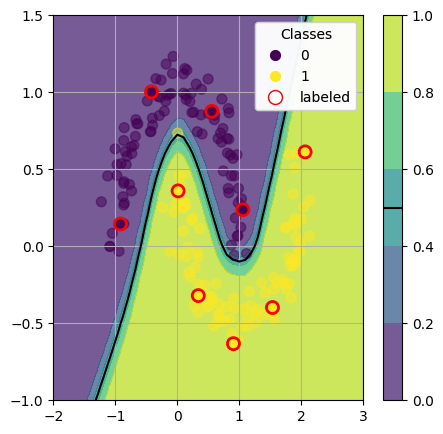

In [89]:
import pylab as plt
from matplotlib.lines import Line2D
import numpy as np

def dataset_to_xy(dataset):
    X, y = [], []
    for batch in dataset:
        X.append(batch[0])
        y.append(batch[1])
    X = torch.stack(X).float()
    y = torch.Tensor(y).long()
    return X, y


@torch.no_grad()
def plot_contour(model, X_l, y_l, X_u=None, y_u=None, ax=None, x_domain=(-3, 3), y_domain=(-3, 3), forward_mode='single'):
    model.eval()
    model.cpu()
    origin = 'lower'
    xx, yy = torch.meshgrid(torch.linspace(x_domain[0], x_domain[1], 51), torch.linspace(y_domain[0], y_domain[1], 51), indexing='ij')
    zz = torch.stack((xx.flatten(), yy.flatten()), dim=1)

    if forward_mode == 'single':
        logits = model(zz)
        probas = logits.softmax(-1)
    elif forward_mode == 'mc':
        logits = model.mc_forward(zz)
        probas = logits.softmax(-1)
        probas = probas.mean(1)
    elif forward_mode == 'mean_field':
        logits = model(zz, mean_field=True)
        probas = logits.softmax(-1)
    else:
        raise NotImplementedError('This forward method is not taken account for. Choose one in [single, mc, mean_field]!')
        

    zz = probas[:, 1].view(xx.shape)

    if X_u != None:
        scatter = plt.scatter(X_l[:, 0], X_l[:, 1], c=y_l, s=75, edgecolors='red', linewidths=2, zorder=5)
        plt.scatter(X_u[:, 0], X_u[:, 1], c=y_u, s=50, alpha=0.5, label='unlabeled')
    else:
        scatter = plt.scatter(X_l[:, 0], X_l[:, 1], c=y_l, s=50, zorder=5, edgecolors='black')

    # Automatically generate a legend
    leg_el = scatter.legend_elements()
    # Add the "labeled" class if there are unlabeled samples present
    if X_u != None:
        leg_el[0].append(Line2D([0], [0], marker='o', color='red', markerfacecolor='white', markeredgecolor='red', markersize=10, linestyle='None'))
        leg_el[1].append("labeled")
    legend1 = plt.legend(*leg_el,
                    loc="upper right", title="Classes")
    plt.gca().add_artist(legend1)

    CS = plt.contourf(xx.numpy(), yy.numpy(), zz.numpy(), alpha=.75, zorder=-1, levels=np.linspace(0, 1, 6), origin=origin)
    CS2 = plt.contour(CS, levels=[0.5], colors='black', origin=origin)
    cbar = plt.colorbar(CS)
    cbar.add_lines(CS2)

    plt.grid(visible=True)

plt.figure(figsize=(5, 5))
X, y = dataset_to_xy(al_datamodule.query_dataset)
X_l, y_l = X[al_datamodule.labeled_indices], y[al_datamodule.labeled_indices]
X_u, y_u = X[al_datamodule.unlabeled_indices], y[al_datamodule.unlabeled_indices]
plot_contour(model, X_l=X_l, y_l=y_l, X_u=X_u, y_u=y_u, x_domain=(-2,3), y_domain=(-1, 1.5))
plt.savefig('readme_example_decision_bounday.png')